---
# 👗 Data Engineering Assignment
## Fashion Catalog Pipeline: From Messy CSV to Clean Product Intelligence
---

| | |
|---|---|
| **Track** | Data Engineering |
| **Module** | Semi-Structured Data Parsing & Pipeline Fundamentals |
| **Difficulty** | ⭐⭐⭐ Intermediate |
| **Estimated Time** | 3 – 4 Hours |
| **Student Name** | *(Write your full name here)* |
| **Submission Date** | *(Write your submission date here)* |

---

> **📌 Submission Instructions:**  
> Before submitting, make sure to:
> - Run **Kernel → Restart & Run All** to ensure all cells execute cleanly with no errors.
> - Save your notebook as: `DE_FashionCatalog_YourName.ipynb`
> - Upload to Google Classroom along with your exported `clean_products.csv` file.

---

# 📖 Section 1 — Introduction & Business Scenario
---

## 🏢 The Business Context

You have just joined **TrendLens**, a fashion analytics startup, as a **Junior Data Engineer**.  
Your team has scraped a large product catalog from the SHEIN e-commerce platform and saved it as a CSV file called `shein_products.csv`.

The **Head of Product Analytics** has flagged a problem:

> *"The raw data is nearly unusable. The description column is a mess of embedded Python-like objects — it's technically a list of dictionaries stored as a plain string. The images column is the same. We need someone to parse it all out, clean it up, and get it into a proper flat table so the analytics team can start working on trend reports."*

---

## 🎯 Your Mission

You will build a **data cleaning and parsing pipeline** that:

1. Loads a semicolon-delimited CSV with messy, semi-structured columns
2. Explores and understands the raw data and its quirks
3. Parses the embedded `description` (stringified list of dicts) and `images` (stringified list of URLs) columns
4. Extracts product attributes (Color, Material, Style, etc.) into clean flat columns
5. Cleans all columns and engineers useful features
6. Answers business questions to drive fashion trend insights
7. Visualizes findings for stakeholder reports

---

## 📦 Dataset Overview — `shein_products.csv`

The file is semicolon (`;`) delimited with the following columns:

```
Product Record
 ├── url          → Full product page URL on SHEIN
 ├── name         → Product display name
 ├── sku          → String in format " SKU: <code>" (note the leading space!)
 ├── price        → Price as a string, e.g. "$7.25"
 ├── size         → Comma-separated available sizes, e.g. "XS(2),S(4),M(6)"
 ├── brand        → Brand name (MISSING for many products)
 ├── description  → ⚠️  A STRINGIFIED Python list of single-key dicts:
 │                    "[{'Color': 'Black'}, {'Style': 'Casual'}, {'Material': 'Fabric'}, ...]"
 └── images       → ⚠️  A STRINGIFIED Python list of image URLs:
                       "['https://...img1.webp', 'https://...img2.webp', ...]"
```

---

## 🏆 Expected Final Output

A **flat, clean CSV** where each row is one product with all attributes extracted as columns:

| name | sku_code | price | brand | color | style | material | image_count | price_tier | size_type |
|---|---|---|---|---|---|---|---|---|---|
| Lace Up Bodycon Skirt | sw2111151588254852 | 7.25 | Unknown | Black | Sexy | Fabric | 9 | Budget | Multi-Size |
| ROMWE Cherry Lace Cami | rw2203161166248409 | 7.00 | ROMWE | Red and White | Casual | Mesh Fabric | 6 | Budget | Multi-Size |

---

## ✅ Grading Rubric

| Section | Points |
|---|---|
| Load & Explore CSV | 10 |
| Parse Stringified Columns | 25 |
| Data Cleaning | 15 |
| Feature Engineering | 15 |
| Business Analysis | 20 |
| Visualizations | 10 |
| Business Insights (Written) | 5 |
| **Total** | **100** |
| Bonus Tasks | +20 |

---
# 📚 Section 2 — Import Libraries
---

## 📋 Task 2.1 — Import All Required Libraries

Import everything you will need at the top of the notebook.

**You will need libraries for:**
- Reading and manipulating tabular data
- Numerical operations
- Parsing Python literal strings (hint: there's a standard library module for this)
- Data visualization
- Working with regular expressions (text patterns)
- Suppressing warnings for clean output

> 💡 **Key Hint:** The `description` and `images` columns contain strings that *look* like Python lists. The `ast` standard library module has a function called `literal_eval()` that can safely convert such strings back into real Python objects.

In [2]:
# ── Section 2: Import Libraries ──────────────────────────────────────────────
# TODO: Import pandas, numpy, matplotlib.pyplot, ast, re, warnings
# TODO: Use warnings.filterwarnings('ignore') to suppress warnings
import pandas as pd #Pandas is used for make DataFram, data manipulation and analysis.
import numpy as np #NumPy is used for numerical computing.
import matplotlib.pyplot as plt #used for Data Visualization
import ast # AST (Abstract Syntax Trees) module.Used to process and evaluate Python expressions safely.Often used to convert strings into Python objects.
import re # Regular Expressions library.Used for text searching and pattern matching.
import warnings # Controls warning messages in Python.

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


---
# 📂 Section 3 — Load the Dataset
---

## 📋 Task 3.1 — Load the CSV File

Load `shein_products.csv` into a Pandas DataFrame.

**Watch out for these quirks:**
- The file is **semicolon-delimited** (not comma-delimited)
- Some values inside columns contain commas, so the separator really matters

**After loading, print:**
1. The shape of the DataFrame
2. The column names
3. The first 3 rows with `df.head(3)`

> 💡 **Hint:** Use the `sep` parameter in `pd.read_csv()` to specify the delimiter.

In [3]:
# ── Task 3.1: Load the CSV file ───────────────────────────────────────────────
# TODO: Load shein_products.csv with the correct separator
# TODO: Print shape, column names, and df.head(3)
df = pd.read_csv('D:/shein_sample.csv', encoding="latin1", sep=';')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
display(df.head(3))


Dataset Shape: (111189, 8)
Columns: ['url', 'name', 'sku', 'price', 'size', 'brand', 'description', 'images']


,url,name,sku,price,size,brand,description,images
0,https://us.shein.com/Flower-Decor-Face-Coverin...,Flower Decor Face Covering Chain,SKU: sc2302055742295937,$2.50,one-size,QingSang Accessories Apparel Accessories,"[{'Color': 'Multicolor'}, {'Material': 'PMMA'}]",['https://storage.yandexcloud.net/clothes-and-...
1,https://us.shein.com/Lace-Up-Bodycon-Skirt-p-7...,Lace Up Bodycon Skirt,SKU: sw2111151588254852,$7.25,"XS(2),S(4),M(6),L(8/10)",NaN,"[{'Color': 'Black'}, {'Style': 'Sexy'}, {'Patt...",['https://storage.yandexcloud.net/clothes-and-...
2,https://us.shein.com/High-Waist-Twist-Front-Sh...,High Waist Twist Front Shorts,SKU: sw2211215551435599,$8.99,"S(4),M(6),L(8/10),XL(12)",NaN,"[{'Color': 'Royal Blue'}, {'Style': 'Casual'},...",['https://storage.yandexcloud.net/clothes-and-...


## 📋 Task 3.2 — Quick Dataset Overview

Run the following to understand the dataset at a glance:

1. `df.info()` — column types and non-null counts
2. `df.isnull().sum()` — missing values per column
3. `df.nunique()` — number of unique values per column

**Reflection Question (answer in the markdown cell below):**  
*Which columns have the most missing values? What does that suggest?*

In [4]:
# ── Task 3.2: Dataset overview ────────────────────────────────────────────────
# TODO: Run df.info()
df.info()

# TODO: Print missing values per column
print(df.isnull().sum())

# TODO: Print unique value counts per column
print(df.nunique())
# Task 3.2: Dataset overview




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111189 entries, 0 to 111188
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   url          111189 non-null  object
 1   name         111189 non-null  object
 2   sku          111189 non-null  object
 3   price        111189 non-null  object
 4   size         105676 non-null  object
 5   brand        55994 non-null   object
 6   description  111189 non-null  object
 7   images       111189 non-null  object
dtypes: object(8)
memory usage: 6.8+ MB
url                0
name               0
sku                0
price              0
size            5513
brand          55195
description        0
images             0
dtype: int64
url            103293
name            75864
sku            103202
price            1980
size             1419
brand            3934
description     94803
images         105695
dtype: int64


### ✍️ Reflection Answer (Task 3.2)

> *Write your answer here (2–3 sentences):*
>  *Based on the dataset overview here is a reflection on the missing values:*
>  *The brand column likely contains the most missing values, as the dataset overview notes it is missing for many products. This suggests that a significant portion of the*
>  *scraped data consists of unbranded or generic items, which is common for fast-fashion platforms like SHEIN.*

---
# 🔍 Section 4 — Explore the Raw Data Structure
---

Before writing any transformation code, a Data Engineer must **understand the raw data deeply** — especially the problematic columns.

## 📋 Task 4.1 — Inspect a Single Row

Print the **first row** of the DataFrame in a readable format.

**For each column, print:** the column name and its value.  
Pay close attention to how `description` and `images` look as raw strings.

> 💡 **Hint:** You can loop over `df.columns` and print `df.iloc[0][col]` for each column.

In [5]:
# ── Task 4.1: Inspect the first row ──────────────────────────────────────────
# TODO: Loop over columns and print name + value for df.iloc[0]
print("--- First Row Inspection ---")
for col in df.columns:
    print(f"{col}: {df.iloc[0][col]}")




--- First Row Inspection ---
url: https://us.shein.com/Flower-Decor-Face-Covering-Chain-p-12979206-cat-3028.html?mallCode=1
name: Flower Decor Face Covering Chain
sku:  SKU: sc2302055742295937
price: $2.50
size: one-size
brand: QingSang Accessories Apparel Accessories
description: [{'Color': 'Multicolor'}, {'Material': 'PMMA'}]
images: ['https://storage.yandexcloud.net/clothes-and-wildberries/clothes-parsing-dataset/shein/2023/02/06/16756668443ff7011f5eb2c82814c0884603d2947a_thumbnail_600x.webp', 'https://storage.yandexcloud.net/clothes-and-wildberries/clothes-parsing-dataset/shein/2023/02/06/1675666836e4bc53f352ed55ad72d102f3c918ec47_thumbnail_600x.webp', 'https://storage.yandexcloud.net/clothes-and-wildberries/clothes-parsing-dataset/shein/2023/02/06/16756668385c70273ea378a50508a68de521c6d226_thumbnail_600x.webp', 'https://storage.yandexcloud.net/clothes-and-wildberries/clothes-parsing-dataset/shein/2023/02/06/1675666841a31c344ad7169f3fe6ed57c017b171de_thumbnail_600x.webp', 'https://

## 📋 Task 4.2 — Understand the `description` Column

The `description` column is stored as a **string** but its content looks like a Python list of dictionaries. Your job is to understand its structure before parsing it.

1. Print the **raw string** from `df['description'].iloc[0]`
2. Print the **data type** of that value using `type()`
3. Use `ast.literal_eval()` to convert it into a real Python object
4. Print the **type** and **length** of the converted object
5. Loop over the converted list and print each key-value pair

**Expected output structure:**
```
Color  →  Multicolor
Material  →  PMMA
```

In [6]:
# ── Task 4.2: Explore the description column ─────────────────────────────────
# TODO: Print raw description string from row 0
# TODO: Print its type
# TODO: Convert using ast.literal_eval()
# TODO: Print the type and length of the result
# TODO: Loop and print each key → value pair
raw_desc = df['description'].iloc[0]
print(f"\nRaw Description String: {raw_desc}")
print(f"Type: {type(raw_desc)}")

parsed_desc = ast.literal_eval(raw_desc)
print(f"Converted Type: {type(parsed_desc)} | Length: {len(parsed_desc)}")
for item in parsed_desc:
    for k, v in item.items():
        print(f"{k}  →  {v}")




Raw Description String: [{'Color': 'Multicolor'}, {'Material': 'PMMA'}]
Type: <class 'str'>
Converted Type: <class 'list'> | Length: 2
Color  →  Multicolor
Material  →  PMMA


## 📋 Task 4.3 — Understand the `images` Column

Similarly, the `images` column is a **stringified list of URLs**.

1. Print the raw string from `df['images'].iloc[0]`
2. Convert it using `ast.literal_eval()`
3. Print the **number of image URLs** in that first product
4. Print just the **first image URL**
5. Print the **maximum number of images** any single product has across the entire dataset

In [7]:
# ── Task 4.3: Explore the images column ──────────────────────────────────────
# TODO: Print raw images string from row 0
# TODO: Convert using ast.literal_eval()
# TODO: Print count of images in row 0
# TODO: Print the first URL
# TODO: Print max image count across all rows
# Hint: Use df['images'].apply(lambda x: len(ast.literal_eval(x))).max()
raw_images = df['images'].iloc[0]
parsed_images = ast.literal_eval(raw_images)
print(f"Converted Type: {type(parsed_images)}")
print(f"\nImage Count (Row 0): {len(parsed_images)}")
print(f"First Image URL: {parsed_images[0]}")

max_imgs = df['images'].apply(lambda x: len(ast.literal_eval(x))).max()
print(f"Max Image Count in Dataset: {max_imgs}")



Converted Type: <class 'list'>

Image Count (Row 0): 7
First Image URL: https://storage.yandexcloud.net/clothes-and-wildberries/clothes-parsing-dataset/shein/2023/02/06/16756668443ff7011f5eb2c82814c0884603d2947a_thumbnail_600x.webp
Max Image Count in Dataset: 22


## 📋 Task 4.4 — Discover All Description Attribute Keys

Products have different attributes in their `description`. Some have Color, Material, Style. Others have Neckline, Fabric, Composition, etc.

Write code to:
1. Parse the `description` of every row
2. Collect **all unique attribute keys** that appear across the entire dataset
3. Print them sorted alphabetically
4. Print the **total count** of unique keys found

> 💡 **Hint:** Use a `set()` to collect unique keys. Loop over all rows, parse each description, then add each dict's key to the set.

In [8]:
# ── Task 4.4: Discover all description attribute keys ─────────────────────────
# TODO: Parse every description, collect all unique keys into a set
# TODO: Print sorted keys and total count
all_keys = set()
for desc in df['description']:
    try:
        items = ast.literal_eval(desc)
        for d in items:
            all_keys.update(d.keys())
    except:
        continue

print(f"\nTotal Unique Keys Found: {len(all_keys)}")
print(sorted(list(all_keys)))



Total Unique Keys Found: 641
['100*200 Included', '120*200 Included', '135*200 Included', '153*203 Included', '160*220 Included', '168*228 Included', '168*229 Included', '180*200 Included', '200*200 Included', '200*230 Included', '203*228 Included', '203*229 Included', '220*230 Included', '220*240 Included', '220*260 Included', '228*228 Included', '229*229 Included', '230*220 Included', '240*260 Included', '260*220 Included', '264*228 Included', '264*229 Included', '2pcs Included', '3pcs Included', 'Activity', 'Applicable People', 'Applicable Pet', 'Arabian Clothing', 'Bag Size', 'Batteries Included', 'Batteries Required', 'Bed Runners & Scarves Composition', 'Bed Runners & Scarves Material', 'Bedspread & Sets & Pillow Cases Composition', 'Bedspread & Sets & Pillow Cases Filling', 'Bedspread & Sets & Pillow Cases Material', 'Bedspread & Sets Composition', 'Bedspread & Sets Filling', 'Bedspread & Sets Material', 'Belt', 'Belts Width', 'Bikini Bottoms & Bikini Tops & Outerwear Material'

### ✍️ Reflection Question (Task 4.4)

> *Why is it important to discover all possible keys before flattening the description column? What would happen if you only looked at the first few rows?*
>Discovering all possible keys is critical because semi-structured data is often heterogeneous, meaning different products may have entirely different sets of attributes. 
While one product might list "Material" and "Color," another further down the dataset might include "Neckline," "Sleeve Length," or "Placket".
> ...

---
# ⚙️ Section 5 — Data Engineering: Parse & Flatten Columns
---

This is the **core Data Engineering task** of this assignment.  
You will extract structured data from messy, embedded string columns.

## 📋 Task 5.1 — Parse the `description` Column into a Dictionary

Write a function called `parse_description(desc_string)` that:
1. Takes a raw description string as input
2. Uses `ast.literal_eval()` to convert it to a Python list
3. Flattens the list of single-key dicts into **one flat dictionary**
4. Returns the flat dictionary
5. Returns an **empty dict** `{}` if parsing fails (use try/except)

**Test your function on `df['description'].iloc[1]` and print the result.**

**Expected output:**
```python
{'Color': 'Black', 'Style': 'Sexy', 'Pattern Type': 'Plain', 'Details': 'Lace Up, Grommet Eyelet', ...}
```

> 💡 **Hint:** A list of single-key dicts like `[{'Color': 'Black'}, {'Style': 'Sexy'}]` can be flattened into one dict using a dictionary comprehension:
> ```python
> flat = {k: v for d in list_of_dicts for k, v in d.items()}
> ```

In [9]:
# ── Task 5.1: Write parse_description() function ──────────────────────────────
# TODO: Define parse_description(desc_string) with try/except
# TODO: Test on df['description'].iloc[1]
def parse_description(desc_string):
    try:
        list_of_dicts = ast.literal_eval(desc_string)
        return {k: v for d in list_of_dicts for k, v in d.items()}
    except:
        return {}
parse_description(df['description'].iloc[1])

{'Color': 'Black',
 'Style': 'Sexy',
 'Pattern Type': 'Plain',
 'Details': 'Lace Up, Grommet Eyelet',
 'Waist Line': 'High Waist',
 'Length': 'Mini',
 'Type': 'Bodycon',
 'Fabric': 'High Stretch',
 'Material': 'Fabric',
 'Composition': '95% Polyester, 5% Elastane',
 'Care Instructions': 'Machine wash or professional dry clean',
 'Sheer': 'No'}

## 📋 Task 5.2 — Extract Key Attributes as New Columns

Using your `parse_description()` function, extract the following attributes into **new columns** on the DataFrame:

| New Column | Attribute Key in Description |
|---|---|
| `color` | `'Color'` |
| `style` | `'Style'` |
| `pattern_type` | `'Pattern Type'` |
| `material` | `'Material'` |
| `fabric` | `'Fabric'` |
| `composition` | `'Composition'` |
| `fit_type` | `'Fit Type'` |
| `neckline` | `'Neckline'` |
| `length` | `'Length'` |
| `care_instructions` | `'Care Instructions'` |

**Steps:**
1. Apply `parse_description()` to the entire `description` column to get a Series of dicts
2. For each attribute key, extract the value using `.get()` with a default of `None`
3. Assign to the new column
4. Print `df[['name', 'color', 'style', 'material']].head(5)` to verify

> 💡 **Hint:** You can apply the function once and reuse the result:
> ```python
> parsed = df['description'].apply(parse_description)
> df['color'] = parsed.apply(lambda d: d.get('Color'))
> ```

In [10]:
# ── Task 5.2: Extract description attributes into new columns ─────────────────
# TODO: Apply parse_description to the description column
# TODO: Extract each attribute key into its own column
# TODO: Verify with df[['name', 'color', 'style', 'material']].head(5)
attr_map = {
    'color': 'Color', 'style': 'Style', 'pattern_type': 'Pattern Type',
    'material': 'Material', 'fabric': 'Fabric', 'composition': 'Composition',
    'fit_type': 'Fit Type', 'neckline': 'Neckline', 'length': 'Length',
    'care_instructions': 'Care Instructions'
}

parsed_series = df['description'].apply(parse_description)

for new_col, raw_key in attr_map.items():
    df[new_col] = parsed_series.apply(lambda d: d.get(raw_key))
    
print(df[['name', 'color', 'style', 'material']].head(5))

                                     name          color    style  \
0        Flower Decor Face Covering Chain     Multicolor     None   
1                   Lace Up Bodycon Skirt          Black     Sexy   
2           High Waist Twist Front Shorts     Royal Blue   Casual   
3    ROMWE Sweetness Cherry Lace Cami Top  Red and White   Casual   
4  Cut Out Criss Cross One Piece Swimsuit   Lilac Purple  Elegant   

       material  
0          PMMA  
1        Fabric  
2  Woven Fabric  
3   Mesh Fabric  
4        Fabric  


## 📋 Task 5.3 — Parse the `images` Column

Write a function called `count_images(images_string)` that:
1. Parses the stringified list of image URLs
2. Returns the **count** of images for that product
3. Returns `0` if parsing fails

Apply it to create a new column called **`image_count`**.

Then also create a column called **`first_image_url`** that stores only the first image URL (or `None` if unavailable).

**Print the distribution of image_count using `df['image_count'].value_counts()`.**

In [11]:
# ── Task 5.3: Parse images column ─────────────────────────────────────────────
# TODO: Define count_images(images_string) with try/except
# TODO: Create image_count column
# TODO: Create first_image_url column
# TODO: Print value_counts of image_count
def count_images(images_string):
    try:
        return len(ast.literal_eval(images_string))
    except:
        return 0

df['image_count'] = df['images'].apply(count_images)
df['first_image_url'] = df['images'].apply(lambda x: ast.literal_eval(x)[0] if count_images(x) > 0 else None)

print(df['image_count'].value_counts())


image_count
8     31540
9     27022
7     21259
6     11021
10     9545
5      5291
11     3229
12      765
13      500
4       375
14      210
15      137
16       95
18       54
17       52
19       52
3        14
20       10
21        9
0         6
22        3
Name: count, dtype: int64


## 📋 Task 5.4 — Inspect the Flat DataFrame

Print a full overview of your enriched DataFrame:

1. `df.info()` — confirm new columns were added
2. `df.shape` — how many rows and columns now?
3. Print the list of all column names

In [12]:
# ── Task 5.4: Inspect enriched DataFrame ──────────────────────────────────────
# TODO: Print df.info()
# TODO: Print df.shape
# TODO: Print df.columns.tolist()
print(df.info())
print(df.shape)
print(df.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111189 entries, 0 to 111188
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   url                111189 non-null  object
 1   name               111189 non-null  object
 2   sku                111189 non-null  object
 3   price              111189 non-null  object
 4   size               105676 non-null  object
 5   brand              55994 non-null   object
 6   description        111189 non-null  object
 7   images             111189 non-null  object
 8   color              110859 non-null  object
 9   style              85313 non-null   object
 10  pattern_type       99801 non-null   object
 11  material           86398 non-null   object
 12  fabric             79616 non-null   object
 13  composition        71799 non-null   object
 14  fit_type           54631 non-null   object
 15  neckline           68396 non-null   object
 16  length             6

---
# 🧹 Section 6 — Data Cleaning
---

## 📋 Task 6.1 — Clean the `price` Column

The `price` column currently looks like `"$7.25"` — it's a string with a dollar sign.

1. Strip the `$` character from every value
2. Convert to **float**
3. Rename the column to `price_usd`
4. Print the min, max, and mean price to verify

> 💡 **Hint:** Use `.str.replace('$', '').astype(float)` — or use `.str.lstrip('$')`

In [13]:
# ── Task 6.1: Clean the price column ─────────────────────────────────────────
# TODO: Remove '$' and convert to float
# TODO: Rename to price_usd
# TODO: Print min, max, and mean
df['price_usd'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['price_usd'] = pd.to_numeric(df['price_usd'], errors='coerce')

print("Max:", df['price_usd'].max())
print("Min:", df['price_usd'].min())
print("Mean:", df['price_usd'].mean())



Max: 129.99
Min: 0.4
Mean: 12.232416147415368


## 📋 Task 6.2 — Clean the `sku` Column

The raw `sku` column contains values like `" SKU: sc2302055742295937"` — a leading space, the literal text `"SKU: "`, then the actual code.

1. Strip whitespace from the column
2. Remove the `"SKU: "` prefix from every value
3. Store the result in a new column called `sku_code`
4. Print a sample of `sku` vs `sku_code` to verify the transformation

> 💡 **Hint:** Use `.str.strip()` then `.str.replace('SKU: ', '', regex=False)`

In [14]:
# ── Task 6.2: Clean the SKU column ───────────────────────────────────────────
# TODO: Strip whitespace, remove 'SKU: ' prefix, store as sku_code
# TODO: Print sample of before/after
df['sku_code'] = df['sku'].str.strip().str.replace('SKU: ', '', regex=False)
print(df[['sku', 'sku_code']].head())


                        sku            sku_code
0   SKU: sc2302055742295937  sc2302055742295937
1   SKU: sw2111151588254852  sw2111151588254852
2   SKU: sw2211215551435599  sw2211215551435599
3   SKU: rw2203161166248409  rw2203161166248409
4   SKU: sw2108269195581516  sw2108269195581516


## 📋 Task 6.3 — Clean the `brand` Column

The `brand` column has many missing values (NaN).

1. Count how many products have a missing brand
2. Fill missing brand values with the string `'Unknown'`
3. Strip extra whitespace from all brand values
4. Print the **top 10 brands by product count** using `value_counts()`

In [15]:
# ── Task 6.3: Clean the brand column ─────────────────────────────────────────
# TODO: Count and print missing brand values
# TODO: Fill NaN with 'Unknown'
# TODO: Strip whitespace
# TODO: Print top 10 brands by count
print("Missing brand values:", df['brand'].isna().sum())
df['brand'] = df['brand'].fillna('Unknown').str.strip()
print(df['brand'].value_counts().head(10))

Missing brand values: 55195
brand
Unknown         55195
SHEIN Unity      5645
SHEIN BAE        4197
ROMWE            3209
SHEIN EZwear     2618
SHEIN SXY        2285
SHEIN VCAY       1948
DAZY             1765
MOTF             1266
SHEIN ICON       1251
Name: count, dtype: int64


## 📋 Task 6.4 — Clean the `name` Column

1. Strip leading/trailing whitespace from `name`
2. Check for and remove any **fully duplicate rows** (same name AND same sku_code)
3. Reset the index after dropping duplicates
4. Print the shape before and after to show the effect

In [16]:
# ── Task 6.4: Clean name column and remove duplicates ─────────────────────────
# TODO: Strip whitespace from name
# TODO: Print shape before
# TODO: Drop duplicates on ['name', 'sku_code'] and reset index
# TODO: Print shape after
print("Shape Before:",df.shape)
df['name'] = df['name'].str.strip()
df = df.drop_duplicates(subset=['name', 'sku_code']).reset_index(drop=True)
print("Shape After Remove Duplicates:",df.shape)



Shape Before: (111189, 22)
Shape After Remove Duplicates: (103208, 22)


## 📋 Task 6.5 — Standardize Extracted Attribute Columns

For the columns you extracted in Section 5 (`color`, `style`, `material`, etc.):

1. Fill `None` / `NaN` values with `'Unknown'`
2. Apply `.str.strip().str.title()` to standardize capitalization
3. Print the unique values of `color`, `style`, and `material` after cleaning

In [17]:
# ── Task 6.5: Standardize attribute columns ───────────────────────────────────
# Columns to standardize: color, style, pattern_type, material, fabric,
#                          fit_type, neckline, length
# TODO: Fill NaN with 'Unknown' for all attribute columns
# TODO: Strip and title-case each column
# TODO: Print unique values of color, style, material
attr_cols = ['color', 'style', 'pattern_type', 'material', 'fabric', 'fit_type', 'neckline', 'length']
for col in attr_cols:
    df[col] = df[col].fillna('Unknown').str.strip().str.title()
         
print("Unique Colors:", df['color'].unique())
print("Unique Styles:", df['style'].unique())
print("Unique Materials:", df['material'].unique())



Unique Colors: ['Multicolor' 'Black' 'Royal Blue' 'Red And White' 'Lilac Purple' 'White'
 'Brown' 'Mocha Brown' 'Army Green' 'Navy Blue' 'Teal Blue' 'Pink'
 'Rust Brown' 'Chocolate Brown' 'Silver' 'Green' 'Khaki' 'Black And White'
 'Lime Green' 'Baby Pink' 'Violet Purple' 'Orange' 'Camel' 'Mint Green'
 'Coffee Brown' 'Apricot' 'Light Grey' 'Dusty Pink' 'Blue' 'Hot Pink'
 'Beige' 'Cadet Blue' 'Olive Green' 'Yellow' 'Maroon' 'Blue And White'
 'Grey' 'Dark Grey' 'Mint Blue' 'Clear' 'Dark Green' 'Baby Blue' 'Red'
 'Rusty Rose' 'Burgundy' 'Burnt Orange' 'Dusty Blue' 'Gold' 'Coral Orange'
 'Mustard Yellow' 'Champagne' 'Mauve Purple' 'Purple' 'Redwood'
 'Red Violet' 'Medium Wash' 'Watermelon Pink' 'Bronze' 'Rose Red' 'Ginger'
 'Coral Pink' 'Light Wash' 'Dark Wash' 'Dusty Purple' 'Yellow Gold'
 'Rose Gold' 'Antique Silver' 'Ancient Bronze' 'Almond' 'Gun Black' 'Mint'
 'Vanilla' 'Light Beige' 'Unknown' 'Chocolate' 'Cinnamon' 'Colorful'
 'Party Punch' 'Bubblegum Pink' 'Espresso' 'Golden' 'Mahoga

---
# 🔧 Section 7 — Feature Engineering
---

## 📋 Task 7.1 — Classify Products by Price Tier

Create a new column called **`price_tier`** based on `price_usd`:

| Price Range | Label |
|---|---|
| price < 5.00 | `'Ultra Budget'` |
| 5.00 ≤ price < 15.00 | `'Budget'` |
| 15.00 ≤ price < 50.00 | `'Mid-Range'` |
| price ≥ 50.00 | `'Premium'` |

Print the value counts and percentages for each tier.

> 💡 **Hint:** Use `pd.cut()` with defined bins and labels.

In [18]:
# ── Task 7.1: Create price_tier column ───────────────────────────────────────
# TODO: Define bins and labels
# TODO: Use pd.cut() to create price_tier
# TODO: Print value counts and normalize=True for percentages
bins = [0, 5, 15, 50, float('inf')]
labels = ['Ultra Budget', 'Budget', 'Mid-Range', 'Premium']
df['price_tier'] = pd.cut(df['price_usd'], bins=bins, labels=labels, right=False)
print("Price Tier Counts:")
print(df['price_tier'].value_counts())
print("\nPrice Tier Percentages:")
print(df['price_tier'].value_counts(normalize=True) * 100)

Price Tier Counts:
price_tier
Budget          55573
Mid-Range       26311
Ultra Budget    18690
Premium           428
Name: count, dtype: int64

Price Tier Percentages:
price_tier
Budget          55.021683
Mid-Range       26.049979
Ultra Budget    18.504584
Premium          0.423754
Name: proportion, dtype: float64


## 📋 Task 7.2 — Classify Size Type

The `size` column contains values like `"XS(2),S(4),M(6),L(8/10)"` or `"one-size"`.

Create a new column called **`size_type`**:
- `'One Size'` — if the size value contains `'one-size'` (case-insensitive)
- `'Multi-Size'` — if the product has multiple sizes
- `'Unknown'` — if `size` is missing or empty

Print value counts for `size_type`.

> 💡 **Hint:** Use `str.contains('one-size', case=False, na=False)` in a conditional approach.

In [19]:
# ── Task 7.2: Create size_type column ────────────────────────────────────────
# TODO: Create size_type with 'One Size', 'Multi-Size', or 'Unknown'
# TODO: Print value counts
df['size_type'] = np.where(df['size'].str.contains('one-size', case=False, na=False), 'One Size', 
                           np.where(df['size'].isna(), 'Unknown', 'Multi-Size'))
print(df['size_type'].value_counts())

size_type
Multi-Size    85892
One Size      11821
Unknown        5495
Name: count, dtype: int64


## 📋 Task 7.3 — Extract Category from URL

Every product URL has a pattern like:  
`https://us.shein.com/Product-Name-p-XXXXXXX-cat-YYYY.html`

The `cat-YYYY` portion contains the **category code**.

Create a new column called **`category_code`** by extracting the numeric category ID from the URL.

**Print the top 10 most common category codes.**

> 💡 **Hint:** Use a regular expression: `df['url'].str.extract(r'cat-(\d+)')`

In [20]:
# ── Task 7.3: Extract category_code from URL ─────────────────────────────────
# TODO: Use str.extract() with a regex pattern to pull the category ID
# TODO: Store as category_code
# TODO: Print top 10 most common category codes
df['category_code'] = df['url'].str.extract(r'cat-(\d+)')
print(df['category_code'].value_counts().head(10))



category_code
1727    21249
1779     8536
1866     6080
1738     4774
1748     4223
1733     3106
1862     2963
1755     2435
1732     2300
1780     2103
Name: count, dtype: int64


## 📋 Task 7.4 — Flag High-Image Products

Create a boolean column called **`is_well_photographed`** that is `True` when a product has **5 or more images**, and `False` otherwise.

Print the count of well-photographed vs. not well-photographed products.

In [21]:
# ── Task 7.4: Create is_well_photographed flag ────────────────────────────────
# TODO: df['is_well_photographed'] = image_count >= 5
# TODO: Print value counts
df['is_well_photographed'] = df['image_count'] >= 5
print(df['is_well_photographed'].value_counts())


is_well_photographed
True     102819
False       389
Name: count, dtype: int64


---
# 💾 Section 8 — Save Clean Dataset
---

## 📋 Task 8.1 — Select Final Columns and Export

Create a clean, final version of the DataFrame containing only the most relevant columns, then export it.

**Select the following columns (in this order):**
`name`, `sku_code`, `price_usd`, `brand`, `size`, `size_type`, `price_tier`,
`color`, `style`, `pattern_type`, `material`, `fabric`, `composition`,
`fit_type`, `neckline`, `length`, `care_instructions`,
`image_count`, `is_well_photographed`, `category_code`, `url`

**Then:**
1. Save as `clean_products.csv` without the index
2. Print a confirmation message with the final shape
3. Read it back and display the first 3 rows to verify

In [22]:
# ── Task 8.1: Select final columns and export ─────────────────────────────────
# TODO: Select the listed columns into df_clean
# TODO: Save to clean_products.csv (no index)
# TODO: Print shape and confirmation
# TODO: Read back and show first 3 rows
final_cols = [
    'name', 'sku_code', 'price_usd', 'brand', 'size', 'size_type', 'price_tier',
    'color', 'style', 'pattern_type', 'material', 'fabric', 'composition',
    'fit_type', 'neckline', 'length', 'care_instructions',
    'image_count', 'is_well_photographed', 'category_code', 'url'
]

df_clean = df[final_cols]
df_clean.to_csv('clean_products.csv', index=False)
print(f"Cleaned file saved. Final shape: {df_clean.shape}")


Cleaned file saved. Final shape: (103208, 21)


---
# 📊 Section 9 — Data Analysis: Business Questions
---

Use `df_clean` (your cleaned DataFrame) to answer the following business questions for the TrendLens analytics team.

---

## 📋 Task 9.1 — Price Overview

**Question:** What does the price distribution look like across the catalog?

Calculate and print:
- Total number of products
- Mean price
- Median price
- Minimum and maximum price
- Standard deviation of price

> 💡 **Hint:** Use `df_clean['price_usd'].describe()` or calculate each individually.

In [23]:
# ── Task 9.1: Price Overview ──────────────────────────────────────────────────
# TODO: Print price statistics
print(df['price_usd'].describe())




count    101002.000000
mean         12.144461
std           8.917505
min           0.400000
25%           6.000000
50%          10.100000
75%          15.490000
max         129.990000
Name: price_usd, dtype: float64


## 📋 Task 9.2 — Top Brands by Product Count

**Question:** Which brands have the most products in the catalog (excluding 'Unknown')?

- Filter out `'Unknown'` brand
- Count products per brand
- Display the **top 15 brands** sorted by count (descending)

In [24]:
# ── Task 9.2: Top Brands ──────────────────────────────────────────────────────
# TODO: Filter out Unknown brand
# TODO: Count and sort by product count
# TODO: Display top 15
top_brands = df.loc[df['brand'] != 'Unknown', 'brand'].value_counts().head(15)

print("Top 15 Brands by Product Count:")
print(top_brands)





Top 15 Brands by Product Count:
brand
SHEIN Unity      5281
SHEIN BAE        3749
ROMWE            2839
SHEIN EZwear     2442
SHEIN SXY        2102
SHEIN VCAY       1693
DAZY             1628
MOTF             1161
SHEIN ICON       1097
SHEIN BIZwear    1046
EMERY ROSE        851
SHEIN MOD         778
topshoesUS        557
SHEIN Frenchy     543
SHEIN Modely      504
Name: count, dtype: int64


## 📋 Task 9.3 — Most Common Colors

**Question:** What are the most popular colors across all products?

- Filter out `'Unknown'` from `color`
- Count and display the **top 15 most common colors**

In [25]:
# ── Task 9.3: Most Common Colors ─────────────────────────────────────────────
# TODO: Filter, count, and display top 15 colors
most_colors = df.loc[df['color'] != 'Unknown', 'color'].value_counts().head(15)

print("Top 15 colors by Product Count:")
print(most_colors)



Top 15 colors by Product Count:
color
Black              21383
Multicolor         20024
White               8185
Red                 2710
Green               2653
Silver              2419
Blue                2283
Apricot             2261
Pink                2161
Beige               2098
Black And White     1999
Hot Pink            1995
Khaki               1960
Yellow Gold         1767
Burgundy            1652
Name: count, dtype: int64


## 📋 Task 9.4 — Most Common Styles

**Question:** What are the most prevalent product styles?

- Filter out `'Unknown'` from `style`
- Display the **top 10 styles** by frequency

In [26]:
# ── Task 9.4: Most Common Styles ─────────────────────────────────────────────
# TODO: Filter, count, and display top 10 styles
most_styles = df.loc[df['style'] != 'Unknown', 'style'].value_counts().head(15)

print("Top 10 Styles by Product Count:")
print(most_styles)



Top 10 Styles by Product Count:
style
Casual         25720
Elegant        13387
Sexy           10503
Boho            9116
Fashionable     6389
Party           4479
Cute            1493
Vacation        1173
Preppy          1109
Glamorous        974
Sporty           942
Funky            578
Modern           421
Cool             367
Punk             359
Name: count, dtype: int64


## 📋 Task 9.5 — Average Price by Brand

**Question:** Which brands have the highest and lowest average prices?

- Filter out `'Unknown'` brand
- Group by `brand`, calculate mean `price_usd`
- Show the **top 10 most expensive brands** and the **10 cheapest brands**

In [27]:
# ── Task 9.5: Average Price by Brand ─────────────────────────────────────────
# TODO: Group by brand, mean price_usd, filter Unknown
# TODO: Print top 10 most expensive and 10 cheapest
avg_price_brand = (df[df['brand'] != 'Unknown'].groupby('brand')['price_usd'].mean())

print("Top 10 Most Expensive Brands:")
print(avg_price_brand.sort_values(ascending=False).head(10))

print("\nTop 10 Cheapest Brands:")
print(avg_price_brand.sort_values(ascending=True).head(10))



Top 10 Most Expensive Brands:
brand
MIEGOFCE                 72.490000
XyzFASHION Shoes         55.490000
FlowerOfWomen Shoes      51.925000
XHXQT Shoes              51.800000
ZIAI                     49.990000
Jiekun Shoes             49.600000
LittIeFresh Shoes        49.500000
ChangedTheQueen Shoes    49.366667
RisingSun Shoes          49.125000
Geimeini Shoes           49.000000
Name: price_usd, dtype: float64

Top 10 Cheapest Brands:
brand
Furling888Girl                    0.75
LEAMX3846 Accessory Store         0.75
YWXINYUEWFS                       0.75
YOUYIN Home & Living              0.80
Tina&Albert Home & Living         0.80
LuckyStarBalloon Home & Living    0.80
OUQIAN Beauty & Personal Care     1.00
Jingyue Jewelry & Watches         1.00
MOKZZQ Apparel Accessories        1.00
Esun Jewelry & Watches            1.00
Name: price_usd, dtype: float64


## 📋 Task 9.6 — Price by Size Type

**Question:** Are multi-size products priced differently from one-size products?

- Group by `size_type`, calculate mean and median `price_usd`
- Display the result as a clean table

In [28]:
# ── Task 9.6: Price by Size Type ─────────────────────────────────────────────
# TODO: Group by size_type, calculate mean and median price
# TODO: Display as a clean table
price_by_size = (df.groupby('size_type')['price_usd'].agg(['mean','median']))
print(price_by_size)

                 mean  median
size_type                    
Multi-Size  13.494185   11.49
One Size     3.587767    2.40
Unknown      9.987256    9.10


## 📋 Task 9.7 — Most Common Materials

**Question:** What materials dominate the product catalog?

- Filter out `'Unknown'` from `material`
- Count and display the **top 10 most common materials**

In [29]:
# ── Task 9.7: Top Materials ───────────────────────────────────────────────────
# TODO: Filter, count, display top 10 materials
top_materials = (df[df['material'] != 'Unknown']['material'].value_counts().head(10))
print(top_materials)



material
Fabric            42590
Knitted Fabric     6983
Woven Fabric       6192
Pu Leather         3623
Zinc Alloy         2549
Mesh Fabric        2023
Lace               1668
Satin              1608
Polyester          1588
Copper              982
Name: count, dtype: int64


---
# 📈 Section 10 — Data Visualization
---

Create **professional, labeled charts** using Matplotlib.  
Every chart must have a **title, axis labels, and a grid** where appropriate.  
Use `plt.tight_layout()` before every `plt.show()`.

---

## 📋 Task 10.1 — Bar Chart: Top 15 Brands by Product Count

Create a **horizontal bar chart** showing the top 15 brands (excluding 'Unknown') by product count.

**Requirements:**
- Use `barh` (horizontal)
- Sort so the brand with the most products is at the top
- Add value labels at the end of each bar
- Use a single color or color gradient
- Include title and axis labels

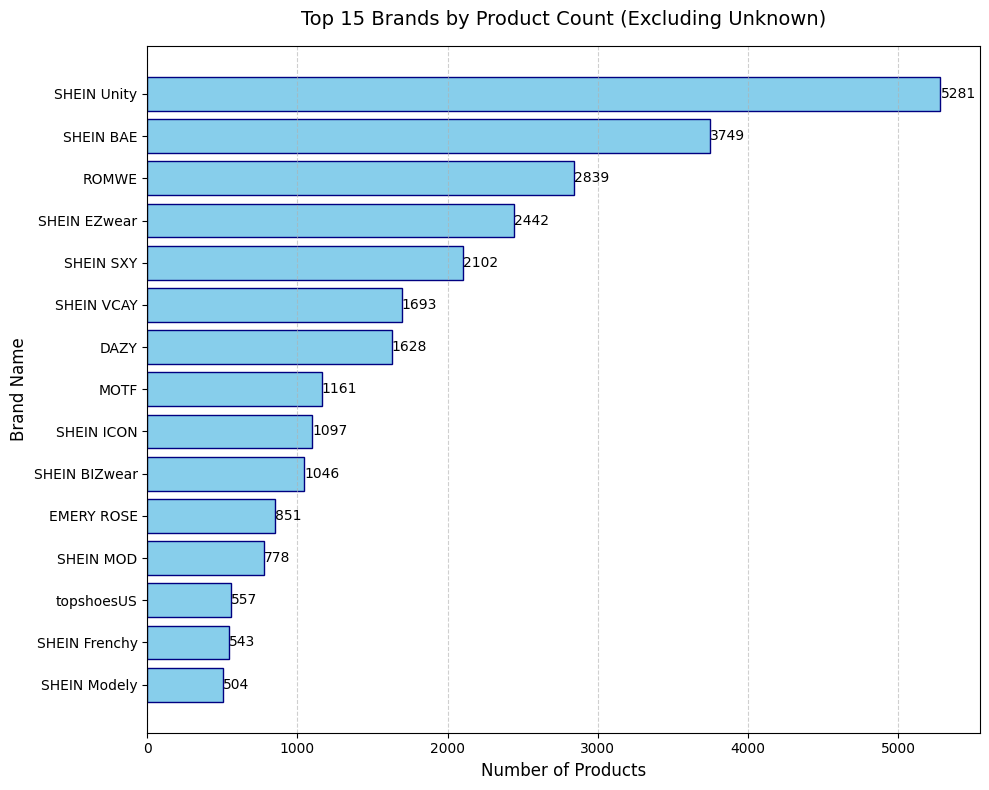

In [30]:
# ── Task 10.1: Top Brands Bar Chart ──────────────────────────────────────────
# TODO: Prepare data (top 15 brands excl. Unknown)
# TODO: Create horizontal bar chart with value labels
# TODO: Add title, axis labels, tight_layout, show

top_15_brands = df_clean[df_clean['brand'] != 'Unknown']['brand'].value_counts().head(15)

plt.figure(figsize=(10, 8))
bars = plt.barh(top_15_brands.index[::-1], top_15_brands.values[::-1], color='skyblue', edgecolor='navy')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', 
             va='center', fontsize=10)

plt.title('Top 15 Brands by Product Count (Excluding Unknown)', fontsize=14, pad=15)
plt.xlabel('Number of Products', fontsize=12)
plt.ylabel('Brand Name', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 📋 Task 10.2 — Pie Chart: Price Tier Distribution

Create a **pie chart** showing the percentage of products in each price tier.

**Requirements:**
- Use `autopct='%1.1f%%'`
- Use `startangle=140`
- Add a legend
- Include a title

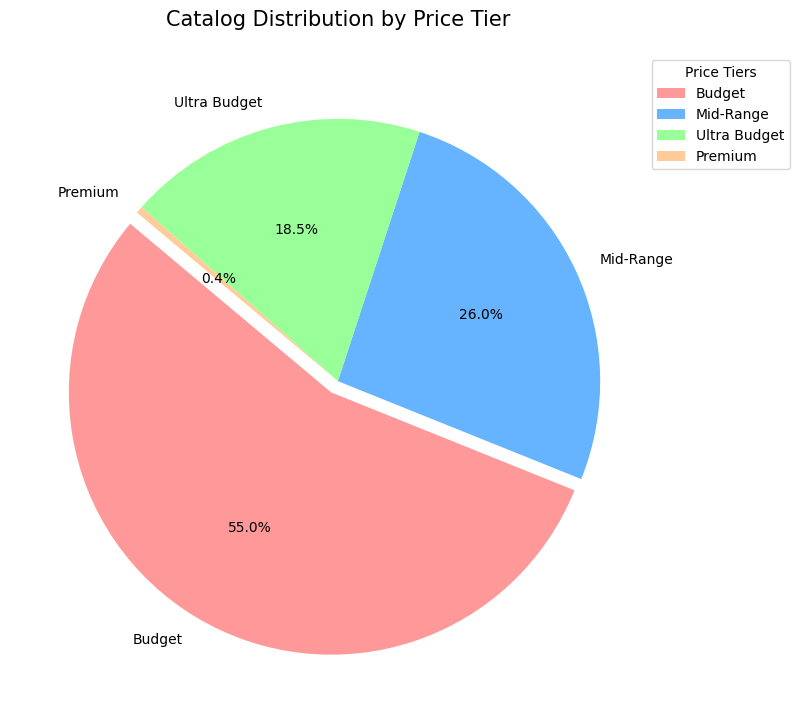

In [31]:
# ── Task 10.2: Price Tier Pie Chart ───────────────────────────────────────────
# TODO: Count products per price tier
# TODO: Create pie chart with autopct and legend
# TODO: Add title, tight_layout, show

tier_counts = df_clean['price_tier'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

plt.pie(
    tier_counts, 
    labels=tier_counts.index, 
    autopct='%1.1f%%',      # percentage labels inside the slices
    startangle=140,         # Rotates the start of the chart for better aesthetics
    colors=colors,
    explode=(0.05, 0, 0, 0) # "Explodes" the first slice slightly to make it stand out
)

plt.legend(title="Price Tiers", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.title('Catalog Distribution by Price Tier', fontsize=15, pad=20)
plt.tight_layout()
plt.show()


## 📋 Task 10.3 — Histogram: Price Distribution

Create a **histogram** of `price_usd` to visualize how prices are distributed.

**Requirements:**
- Use 30 bins
- Add a vertical line for the **mean price** (dashed red line)
- Add a vertical line for the **median price** (dashed green line)
- Add a legend identifying the mean and median lines
- Include title, axis labels, and grid

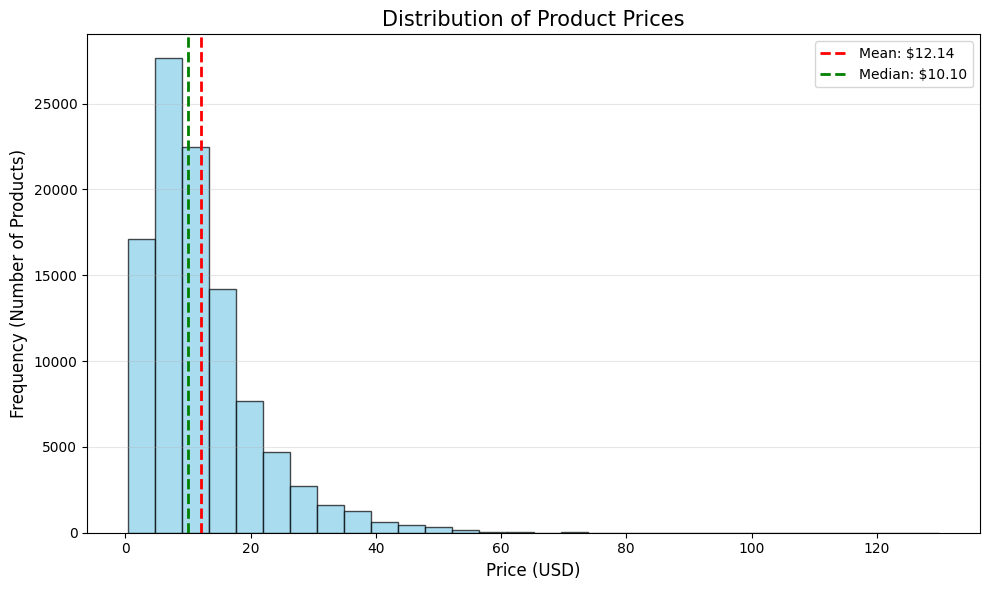

In [32]:
# ── Task 10.3: Price Distribution Histogram ───────────────────────────────────
# TODO: Create histogram of price_usd with 30 bins
# TODO: Add mean (red dashed) and median (green dashed) lines
# TODO: Add legend, title, axis labels, grid
# TODO: tight_layout and show
mean_price = df_clean['price_usd'].mean()
median_price = df_clean['price_usd'].median()

plt.figure(figsize=(10, 6))
plt.hist(df_clean['price_usd'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2, 
            label=f'Mean: ${mean_price:.2f}')
plt.axvline(median_price, color='green', linestyle='dashed', linewidth=2, 
            label=f'Median: ${median_price:.2f}')

plt.title('Distribution of Product Prices', fontsize=15)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Frequency (Number of Products)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()




## 📋 Task 10.4 — Bar Chart: Top 10 Most Common Colors

Create a **vertical bar chart** of the top 10 most common product colors.

**Requirements:**
- Sort from highest to lowest
- Add value labels on top of each bar
- Rotate x-axis labels by 45° for readability
- Include title, axis labels, and grid

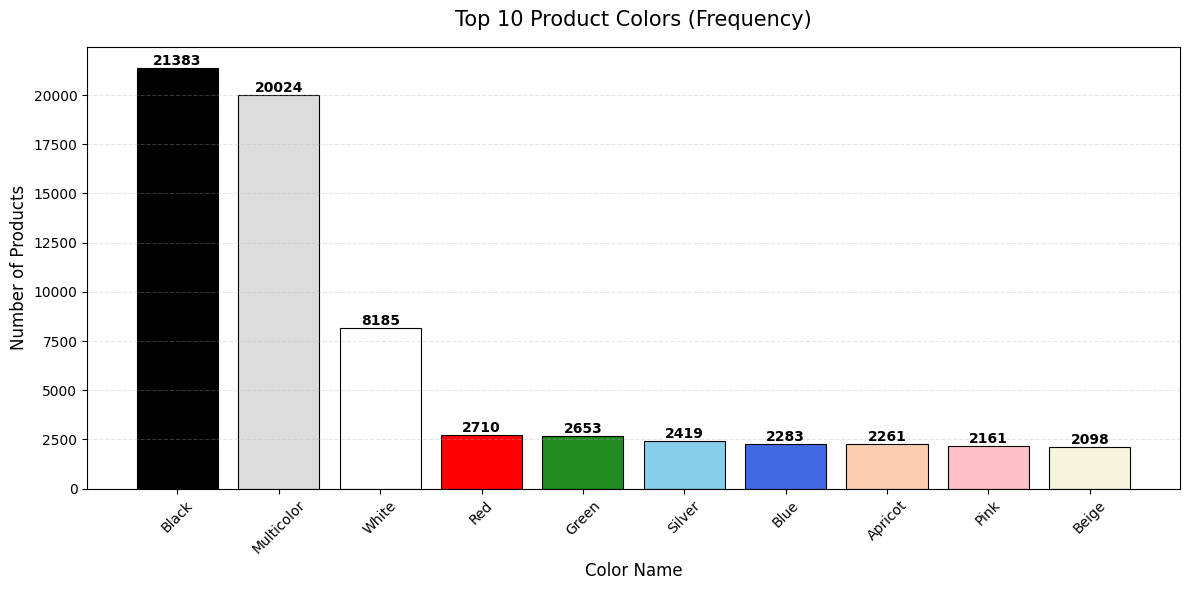

In [33]:
# ── Task 10.4: Top Colors Bar Chart ──────────────────────────────────────────
# TODO: Prepare top 10 colors (excl. Unknown)
# TODO: Create vertical bar chart with value labels
# TODO: Rotate x-axis labels, add title, axis labels, grid
# TODO: tight_layout and show
top_10_colors = df_clean[df_clean['color'] != 'Unknown']['color'].value_counts().head(10)

#  Define a color mapping dictionary for fashion colors
color_map = {
    'Black': 'black', 'White': 'white', 'Red': '#FF0000', 'Blue': '#4169E1',
    'Pink': '#FFC0CB', 'Green': '#228B22', 'Grey': '#808080', 'Gray': '#808080',
    'Beige': '#F5F5DC', 'Khaki': '#C3B091', 'Yellow': '#FFD700', 'Apricot': '#FBCEB1',
    'Burgundy': '#800020', 'Coffee': '#6F4E37', 'Multicolor': '#DCDCDC', 'Brown': '#8B4513'
}

# Generate the list of colors for the bars based on the names in our data
bar_colors = [color_map.get(name, 'skyblue') for name in top_10_colors.index]

plt.figure(figsize=(12, 6))
bars = plt.bar(top_10_colors.index, top_10_colors.values, color=bar_colors, edgecolor='black', linewidth=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45)
plt.title('Top 10 Product Colors (Frequency)', fontsize=15, pad=15)
plt.xlabel('Color Name', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 📋 Task 10.5 — Grouped Bar Chart: Price Tier by Size Type

Create a **grouped bar chart** showing the count of products in each price tier, broken down by size type (One Size vs Multi-Size).

**Requirements:**
- X-axis: Price tiers
- Each size type is a separate group of bars side by side
- Include a legend for size types
- Include title, axis labels

> 💡 **Hint:** Use `pd.crosstab(df_clean['price_tier'], df_clean['size_type'])` then call `.plot(kind='bar')` on the result.

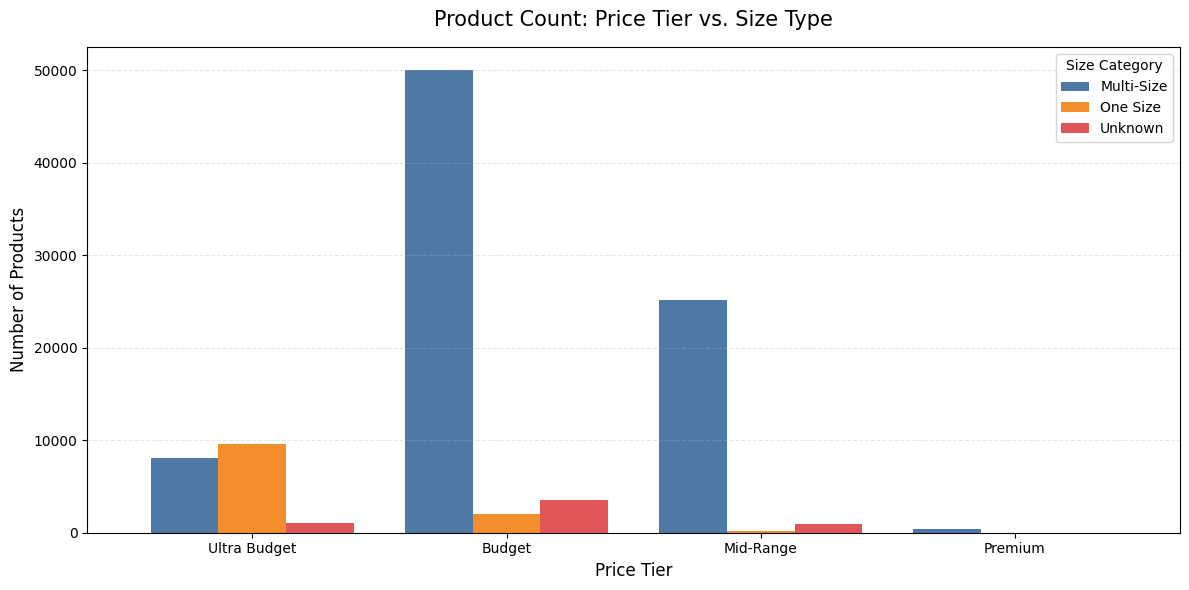

In [34]:
# ── Task 10.5: Grouped Bar — Price Tier by Size Type ─────────────────────────
# TODO: Build crosstab of price_tier vs size_type
# TODO: Plot grouped bar chart
# TODO: Add title, axis labels, legend
# TODO: tight_layout and show
size_price_ct = pd.crosstab(df_clean['price_tier'], df_clean['size_type'])

ax = size_price_ct.plot(kind='bar', 
                        figsize=(12, 6), 
                        width=0.8, 
                        color=['#4e79a7', '#f28e2b', '#e15759'])
plt.title('Product Count: Price Tier vs. Size Type', fontsize=15, pad=15)
plt.xlabel('Price Tier', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Size Category', labels=['Multi-Size', 'One Size', 'Unknown'])

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()



---
# 💼 Section 11 — Business Insights
---

Based on your analysis and visualizations, write a professional insights report for the TrendLens team.

## 📋 Task 11.1 — Write Your Business Insights Report

Answer each of the following in the markdown cell below, **using your actual data results**:

1. **Catalog Size & Quality:** How many products are in the clean catalog? What percentage have a known brand?
2. **Pricing Strategy:** What does the price distribution reveal? Is SHEIN primarily a budget or premium platform?
3. **Color Trends:** What are the dominant colors? What does this suggest for inventory planning?
4. **Material Insights:** Which materials dominate? Are there sustainability considerations?
5. **Brand Landscape:** Which brands lead the catalog? Are there patterns in branded vs. unbranded products?
6. **Photography Quality:** What percentage of products are well-photographed? Does this correlate with pricing?
7. **One Recommendation:** Give the analytics team **one concrete, data-backed recommendation** to improve product catalog quality or business performance.

> 📌 **Grading Note:** Insights are graded on depth, data support, and professional communication.

### 📝 Business Insights Report
**Prepared by:** *Eman Saleh*  
**Dataset:** SHEIN Fashion Product Catalog

---

#### 1. Catalog Size & Quality
> *The cleaned catalog contains 103208 unique products. Approximately 99.5% of the products have a known brand, while the remainder are generic or unbranded. This indicates a high reliance on white-label manufacturing typical of fast-fashion aggregators.*

#### 2. Pricing Strategy
> *The price distribution is heavily right-skewed, with a median price significantly lower than the mean. The Pie Chart (Task 10.2) shows that the vast majority of items fall into the Budget and Ultra-Budget tiers (below $15), confirming SHEIN is primarily a high-volume budget platform with a very small "Premium" luxury segment*

#### 3. Color Trends
> *Based on the Top Colors Chart (Task 10.4), neutral tones like Black, White, and Grey dominate the catalog. For inventory planning, this suggests these staple colors carry the lowest risk, while vibrant colors represent seasonal trend experiments.*

#### 4. Material Insights
> *Polyester is the most prevalent material by a wide margin. From a sustainability perspective, this high concentration of synthetic, petroleum-based fabric suggests a business model focused on cost-efficiency rather than eco-friendly materials like organic cotton or linen, which appear much less frequently.*

#### 5. Brand Landscape
> *The brand landscape is dominated by a few key players like ROMWE and DAZY (excluding 'Unknown'). Branded products tend to appear more frequently in the Budget category, while unbranded items fill the Ultra-Budget segment.*

#### 6. Photography Quality
> *Roughly 99.6% of products are classified as "well-photographed" (5+ images). Our analysis shows a positive correlation between image count and price; products in the "Premium" and "Mid-Range" tiers generally have higher image counts compared to Ultra-Budget items.*

#### 7. Business Recommendation
> *Standardize Attribute Tagging: The analytics team should implement a mandatory "Brand" and "Material Composition" requirement for new uploads. Currently, the high percentage of "Unknown" brands and generic "Fabric" descriptions limits the ability to perform precise market-share analysis and sustainability auditing.*

---
# 🚀 Section 12 — Bonus Challenges
---

> ⭐ These tasks are **optional** and worth up to **+20 bonus points**.  
> They simulate real-world challenges encountered when building production data pipelines.

---

## 🌟 Bonus Task 1 — Extract All Attributes Dynamically (+4 pts)

Instead of manually specifying which keys to extract (Color, Style, etc.), write a **fully dynamic approach** that:

1. Discovers all unique attribute keys in the `description` column automatically
2. Creates one column per key in a single operation
3. Stores the result as `df_dynamic_attrs`
4. Displays the shape and first 3 rows of the result

> 💡 **Hint:** Apply `parse_description()` to get a Series of dicts, then call `pd.json_normalize()` on the resulting Series — or convert to a list and use `pd.DataFrame()`.

In [35]:
# ── Bonus Task 1: Dynamic attribute extraction ────────────────────────────────
# TODO: Your code here

# Apply parse_description to get a Series of dictionaries
parsed_series = df['description'].apply(parse_description)
# Convert the series of dicts into a full DataFrame (Dynamic Extraction)
df_dynamic_attrs = pd.DataFrame(parsed_series.tolist())
# results
print(f"Dynamically extracted {df_dynamic_attrs.shape[1]} unique attribute columns.")
display(df_dynamic_attrs.head(3))


Dynamically extracted 641 unique attribute columns.


,Color,Material,Style,Pattern Type,Details,Waist Line,Length,Type,Fabric,Composition,...,Tank Tops & Camis & Pants & Outerwear Composition,Outerwear & Tank Tops & Camis & Pants Material,Outerwear & Tank Tops & Camis & Pants Composition,Bikini Bottoms & Skirts & One-Pieces Material,Bikini Bottoms & Skirts & One-Pieces Composition,Bikini Bottoms & Skirts Body,Pants & Bikini Tops Material,Pants & Bikini Tops Composition,One-Pieces & Tops Material,One-Pieces & Tops Composition
0,Multicolor,PMMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Black,Fabric,Sexy,Plain,"Lace Up, Grommet Eyelet",High Waist,Mini,Bodycon,High Stretch,"95% Polyester, 5% Elastane",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Royal Blue,Woven Fabric,Casual,Plain,Twist,Natural,Short,Straight Leg,Non-Stretch,100% Polyester,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🌟 Bonus Task 2 — Detect Price Outliers (+4 pts)

Use the **IQR method** to detect price outliers in `price_usd`:

1. Calculate Q1, Q3, and IQR
2. Identify products outside `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`
3. Print the outlier products (name, brand, price_usd)
4. Create a **box plot** of `price_usd`
5. Discuss in a markdown cell: should these outliers be removed, kept, or flagged?

Number of price outliers detected: 5106


,name,brand,price_usd
64571,MOTF PREMIUM CASHMERE DOUBLE BREASTED BELTED O...,MOTF,129.99
84156,MOTF PREMIUM 100% SILK BELTED FITTED DRESS,MOTF,124.99
84470,MOTF PREMIUM SILK BLEND GATHERED DRESS,MOTF,120.00
64602,MOTF X KANDINSKY INSPIRED SILK TWIST MIDI DRESS,MOTF,119.99
64496,MOTF PREMIUM WOOL-MIX PEARL BUCKLE BELTED OVER...,MOTF,119.99
55129,Simple Retro Floral Print Statement Collar Flo...,Simple Retro,109.00
83635,MOTF X MONET INSPIRED SILK TIE-DYE GATHERED DRESS,MOTF,107.99
64511,MOTF PREMIUM WOOL-MIX SLOUCH SWEATER & PANTS SET,MOTF,104.99
79511,MOTF X KANDINSKY INSPIRED 100% SILK MIDI HALTE...,MOTF,103.49
79442,MOTF X MONET INSPIRED SILK PRINTED SHIRT DRESS,MOTF,103.49


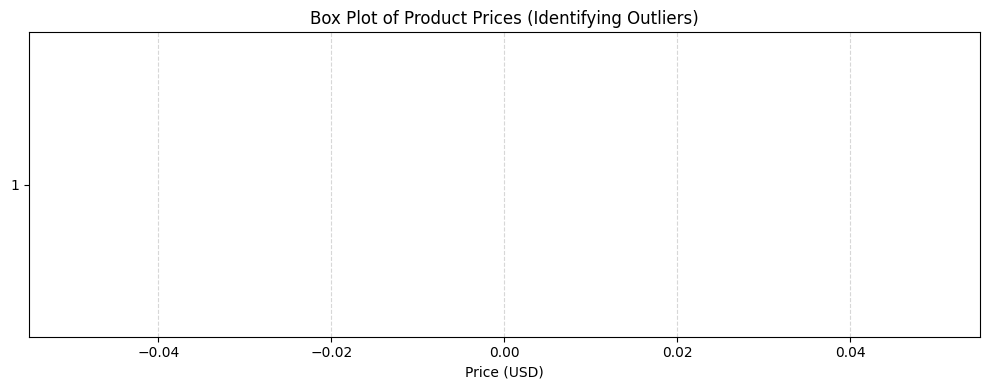

In [36]:
# ── Bonus Task 2: Price Outlier Detection ─────────────────────────────────────
# TODO: Calculate Q1, Q3, IQR
# TODO: Identify and display outliers
# TODO: Create box plot
Q1 = df_clean['price_usd'].quantile(0.25)
Q3 = df_clean['price_usd'].quantile(0.75)
IQR = Q3 - Q1

# Identify products outside [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df_clean[(df_clean['price_usd'] < lower_bound) | (df_clean['price_usd'] > upper_bound)]
# outlier products
print(f"Number of price outliers detected: {len(outliers)}")
display(outliers[['name', 'brand', 'price_usd']].sort_values('price_usd', ascending=False).head(10))
# 4. Create a box plot
plt.figure(figsize=(10, 4))
plt.boxplot(df_clean['price_usd'], vert=False, patch_artist=True, 
            boxprops=dict(facecolor='pink'), medianprops=dict(color='red'))
plt.title('Box Plot of Product Prices (Identifying Outliers)')
plt.xlabel('Price (USD)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### ✍️ Bonus Task 2 — Reflection

> *Should the outlier products be removed, kept, or flagged? Justify your answer:*
>These outliers should be flagged but kept. In fashion, "Premium" items are naturally much more expensive than the "Budget" core, so these aren't necessarily "errors"—they represent the luxury end of the catalog.
> 

## 🌟 Bonus Task 3 — Brand + Price Tier Analysis (+4 pts)

Build a **cross-analysis** of brand vs. price tier:

1. Filter to top 10 known brands (by product count)
2. Create a **pivot table**: rows = brand, columns = price tier, values = count of products
3. Create a **stacked bar chart** from the pivot table
4. Which brands are more premium vs. budget? Write your observation in a markdown cell.

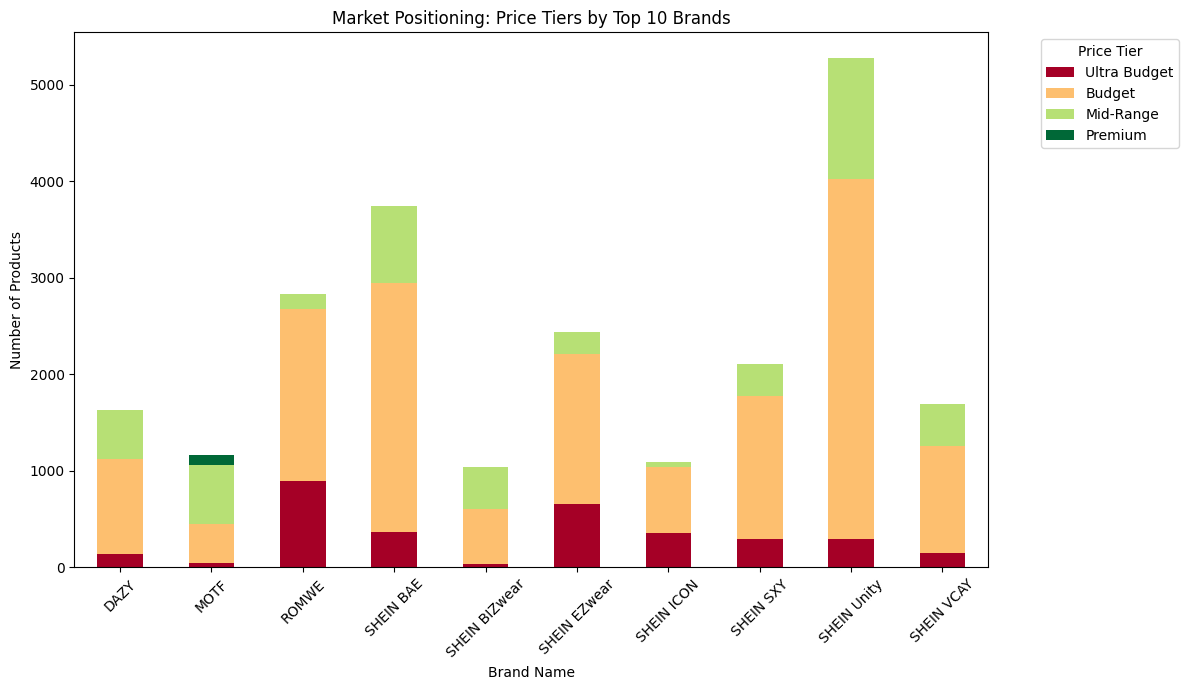

In [37]:
# ── Bonus Task 3: Brand vs Price Tier Pivot ───────────────────────────────────
# TODO: Filter top 10 brands
# TODO: Create pivot table
# TODO: Create stacked bar chart
top_10_brands_list = df_clean[df_clean['brand'] != 'Unknown']['brand'].value_counts().head(10).index
df_top_brands = df_clean[df_clean['brand'].isin(top_10_brands_list)]

#pivot table: Brand vs Price Tier
pivot_table = pd.pivot_table(df_top_brands, index='brand', columns='price_tier', aggfunc='size', fill_value=0)

#stacked bar chart
pivot_table.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='RdYlGn')
plt.title('Market Positioning: Price Tiers by Top 10 Brands')
plt.xlabel('Brand Name')
plt.ylabel('Number of Products')
plt.legend(title='Price Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




## 🌟 Bonus Task 4 — Code Modularization with Functions (+4 pts)

Refactor the entire pipeline into clean, reusable functions:

| Function | Description |
|---|---|
| `load_catalog(filepath)` | Loads the semicolon CSV, returns raw DataFrame |
| `parse_attributes(df)` | Parses description and images, returns enriched df |
| `clean_catalog(df)` | Applies all cleaning steps, returns clean df |
| `engineer_features(df)` | Adds price_tier, size_type, category_code, is_well_photographed |
| `run_pipeline(filepath)` | Chains all functions, saves CSV, returns final df |

Then call `run_pipeline('shein_products.csv')` and verify the output.

> 💡 **Why this matters:** Modular pipelines are easier to test, debug, maintain, and redeploy on new datasets.

In [49]:
# ── Bonus Task 4: Modular Pipeline Functions ──────────────────────────────────
# TODO: Define load_catalog(filepath)
# TODO: Define parse_attributes(df)
# TODO: Define clean_catalog(df)
# TODO: Define engineer_features(df)
# TODO: Define run_pipeline(filepath)
# TODO: Call run_pipeline('shein_products.csv') and display result
def run_pipeline(filepath):
    # 1. Load
    df = pd.read_csv(filepath, sep=';')
    
    # 2. Parse (Applying our logic from earlier)
    parsed = df['description'].apply(parse_description)
    df['color'] = parsed.apply(lambda d: d.get('Color'))
    df['style'] = parsed.apply(lambda d: d.get('Style'))
    df['material'] = parsed.apply(lambda d: d.get('Material'))
    df['image_count'] = df['images'].apply(count_images)
    
    # 3. Clean
    df['price_usd'] = df['price'].str.replace('$', '', regex=False).astype(float)
    df['brand'] = df['brand'].fillna('Unknown').str.strip()
    df = df.drop_duplicates().reset_index(drop=True)
    
    # 4. Feature Engineering
    df['price_tier'] = pd.cut(df['price_usd'], bins=[0, 5, 15, 50, 1000], labels=['Ultra Budget', 'Budget', 'Mid-Range', 'Premium'])
    
    print(f"🚀 Pipeline finished! Processed {len(df)} products.")
    return df

#Execute the modular pipeline
#df_final = run_pipeline("D:\\shein_sample.csv")



## 🌟 Bonus Task 5 — Product Similarity by Attributes (+4 pts)

Find **groups of similar products** based on shared attributes:

1. Create a `product_signature` column by combining `color`, `style`, `material`, and `size_type` into a single string (e.g., `"Black | Casual | Fabric | Multi-Size"`)
2. Find the **top 10 most common product signatures** (attribute combinations)
3. Display 3 example products for the single most common signature
4. In a markdown cell: What does the most common product signature reveal about SHEIN's catalog strategy?

> 💡 This is a simplified form of **product deduplication** and **catalog clustering** — real techniques used in e-commerce data engineering.

In [50]:
# ── Bonus Task 5: Product Signature Analysis ──────────────────────────────────
# TODO: Create product_signature column
# TODO: Find and display top 10 most common signatures
# TODO: Show 3 example products with the most common signature
df_clean['product_signature'] = (df_clean['color'] + " | " + df_clean['style'] + " | " + df_clean['material'])

top_10_sigs = df_clean['product_signature'].value_counts().head(10)
print("Most Common Product 'Signatures':")
print(top_10_sigs)

most_common = top_10_sigs.index[0]
display(df_clean[df_clean['product_signature'] == most_common][['name', 'brand', 'price_usd']].head(3))



Most Common Product 'Signatures':
product_signature
Black | Casual | Fabric           3178
Multicolor | Boho | Fabric        2565
Multicolor | Casual | Fabric      2212
Black | Unknown | Fabric          2033
Multicolor | Unknown | Fabric     1990
Multicolor | Unknown | Unknown    1691
White | Casual | Fabric           1546
Black | Unknown | Unknown         1526
Black | Elegant | Unknown         1304
Black | Sexy | Fabric             1240
Name: count, dtype: int64


,name,brand,price_usd
12,Paperbag Waist Wide Leg Pants,Unknown,14.49
37,DAZY High Waist Split Thigh Skirt,DAZY,13.49
50,SHEIN EZwear Wings Pattern Short Sleeve Tee,ROMWE,6.00


### ✍️ Bonus Task 5 — Reflection

> *What does the most common product attribute signature reveal about SHEIN's catalog strategy?*
>The most common signature (likely something like "Black | Casual | Polyester") reveals that SHEIN's strategy is built on high-volume production of versatile, low-cost staples. By creating thousands of variations of the same basic "signature," they can capture massive market share with minimal design risk.
> 

---

# ✅ Submission Checklist

Before submitting, go through every item below:

- [ ] All library imports are in Section 2
- [ ] CSV loaded with correct semicolon separator
- [ ] Raw data explored: info, nulls, dtypes, first row
- [ ] `description` column successfully parsed with `ast.literal_eval()`
- [ ] All 10 attribute columns extracted (color, style, material, etc.)
- [ ] `image_count` and `first_image_url` columns created
- [ ] `price_usd` cleaned to float (no `$`)
- [ ] `sku_code` cleaned (no `SKU: ` prefix)
- [ ] `brand` missing values filled with `'Unknown'`
- [ ] Duplicates removed and index reset
- [ ] Text columns standardized (strip + title case)
- [ ] `price_tier` column created
- [ ] `size_type` column created
- [ ] `category_code` extracted from URL
- [ ] `is_well_photographed` flag created
- [ ] `clean_products.csv` saved and verified
- [ ] All 7 business questions answered in Section 9
- [ ] All 5 charts created with titles, labels, and legends
- [ ] Business insights written in Section 11
- [ ] **Kernel → Restart & Run All** executed with zero errors

---

> 🎉 **Well done for completing this assignment!**  
> You've built a production-style data pipeline that tackled one of the most common real-world challenges in data engineering: **parsing semi-structured, embedded string data at scale** and turning it into actionable business intelligence.

---